<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Causal_Effects_of_Lifestyle_Interventions_on_Obesity_Transitions_A_Counterfactual_Analysis_Using_Double_Debiased_Machine_Learning_on_Mixed_Real_Synthetic_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


✅ Libraries Imported Successfully!

Dataset Shape: (2111, 17)
Target Distribution:
 NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


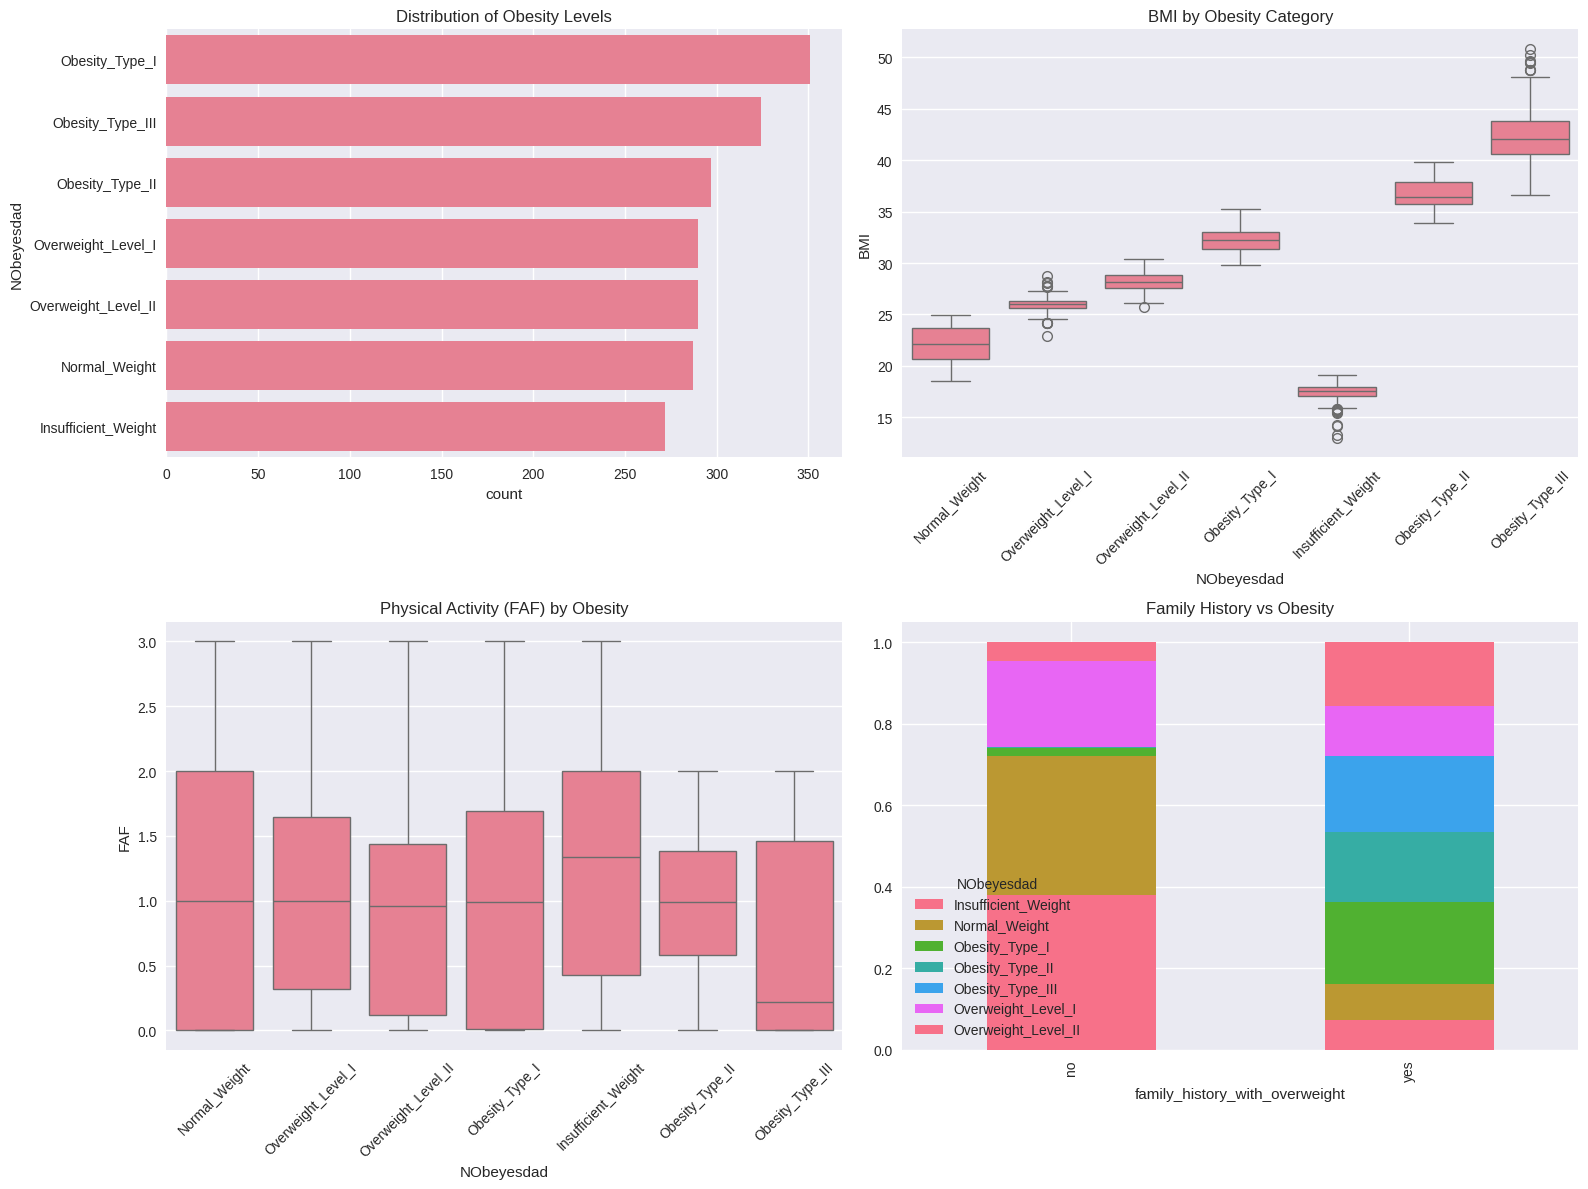

Preprocessing Complete → 23 features

=== High Physical Activity (FAF) ===
              coef   std err         t     P>|t|     2.5 %    97.5 %
FAF_high -0.122856  0.025985 -4.727976  0.000002 -0.173785 -0.071926

=== High Water Intake (CH2O) ===
               coef   std err         t         P>|t|     2.5 %    97.5 %
CH2O_high -0.174825  0.024951 -7.006728  2.439565e-12 -0.223728 -0.125922

=== Low Screen Time (TUE) ===
             coef   std err         t     P>|t|     2.5 %    97.5 %
TUE_low  0.083119  0.031069  2.675324  0.007466  0.022225  0.144012

ROBUSTNESS CHECKS

Physical Activity - Different Thresholds:
  Q0.25 (0.12): ATE = -0.3434
  Q0.5 (1.00): ATE = -0.1415
  Q0.75 (1.67): ATE = -0.2875

--- Different ML Learners (FAF_high) ---
Random Forest: ATE = -0.2632
XGBoost: ATE = -0.2405

ROBUSTNESS SUMMARY:
             Model  ATE_High_FAF
0  LightGBM (Main)       -0.1229
1    Random Forest       -0.2632
2          XGBoost       -0.2405

Generating SHAP plots...


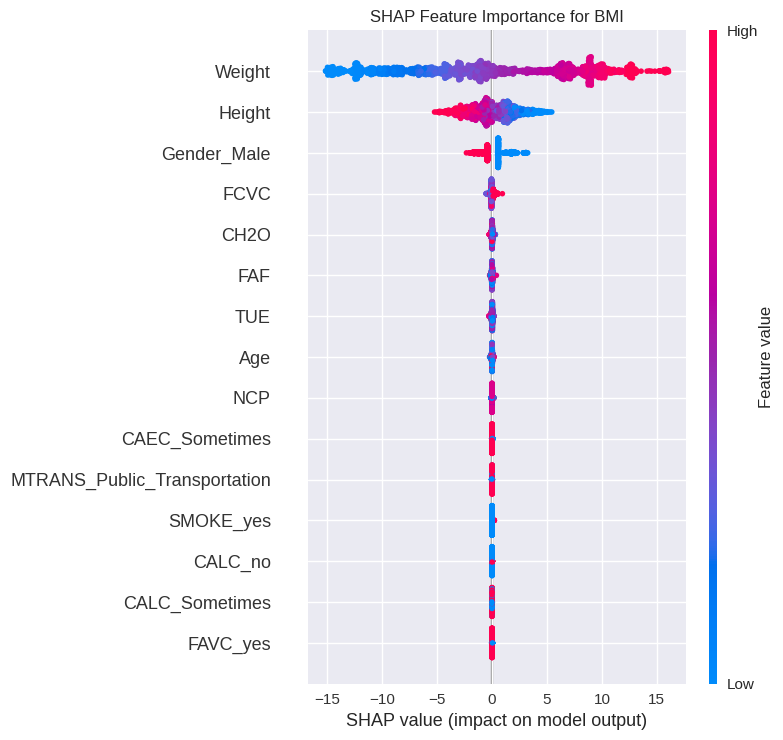


🎉 FULL ANALYSIS COMPLETED SUCCESSFULLY!
All figures saved with high resolution.


In [18]:
# ========================================================
# Q1-LEVEL PAPER CODE: Causal Effects of Lifestyle
# Interventions on Obesity using Double/Debiased ML
# ========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ====================== 1. INSTALL & IMPORT ======================
!pip install doubleml lightgbm xgboost scikit-learn shap -q

import doubleml as dml
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import shap
import xgboost as xgb

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✅ Libraries Imported Successfully!\n")

# ====================== 2. LOAD DATA ======================
df = pd.read_csv('/content/drive/MyDrive/Dataset/ObesityDataSet_raw_and_data_sinthetic.csv')

print("Dataset Shape:", df.shape)
print("Target Distribution:\n", df['NObeyesdad'].value_counts())

# ====================== 3. FEATURE ENGINEERING & EDA ======================
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# --- Key Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(data=df, y='NObeyesdad', ax=axes[0,0], order=df['NObeyesdad'].value_counts().index)
axes[0,0].set_title('Distribution of Obesity Levels')

sns.boxplot(data=df, x='NObeyesdad', y='BMI', ax=axes[0,1])
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=45)
axes[0,1].set_title('BMI by Obesity Category')

sns.boxplot(data=df, x='NObeyesdad', y='FAF', ax=axes[1,0])
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45)
axes[1,0].set_title('Physical Activity (FAF) by Obesity')

pd.crosstab(df['family_history_with_overweight'], df['NObeyesdad'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1,1])
axes[1,1].set_title('Family History vs Obesity')

plt.tight_layout()
plt.savefig('fig1_eda.png', dpi=300, bbox_inches='tight')
plt.show()

# ====================== 4. PREPROCESSING ======================
numerical_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC',
                       'SMOKE', 'SCC', 'CALC', 'MTRANS']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
])

X = df[numerical_features + categorical_features]
X_encoded = preprocessor.fit_transform(X)

cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = numerical_features + list(cat_feature_names)

X_encoded_df = pd.DataFrame(X_encoded, columns=feature_names)

print(f"Preprocessing Complete → {X_encoded_df.shape[1]} features")

# ====================== 5. TREATMENT DEFINITION ======================
df['FAF_high'] = (df['FAF'] >= df['FAF'].median()).astype(int)
df['CH2O_high'] = (df['CH2O'] >= df['CH2O'].median()).astype(int)
df['TUE_low'] = (df['TUE'] <= df['TUE'].median()).astype(int)

# ====================== 6. DOUBLE ML MODELS ======================
ml_g = LGBMRegressor(n_estimators=400, learning_rate=0.05, max_depth=7, random_state=42, verbose=-1)
ml_m = LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=7, random_state=42, verbose=-1)

def run_doubleml(treat_col, label):
    dml_data = dml.DoubleMLData(
        pd.concat([X_encoded_df.reset_index(drop=True),
                   df[['BMI', treat_col]].reset_index(drop=True)], axis=1),
        y_col='BMI', d_cols=treat_col, x_cols=feature_names)

    dml_irm = dml.DoubleMLIRM(dml_data, ml_g=ml_g, ml_m=ml_m,
                              n_folds=5, n_rep=2, trimming_threshold=0.01)
    dml_irm.fit()
    print(f"\n=== {label} ===")
    print(dml_irm.summary)
    return dml_irm

print("="*70)
results = {}
results['FAF'] = run_doubleml('FAF_high', 'High Physical Activity (FAF)')
results['CH2O'] = run_doubleml('CH2O_high', 'High Water Intake (CH2O)')
results['TUE'] = run_doubleml('TUE_low', 'Low Screen Time (TUE)')

# ====================== 7. ROBUSTNESS CHECKS ======================
print("\n" + "="*80)
print("ROBUSTNESS CHECKS")
print("="*80)

# 7.1 Different Thresholds
def robustness_thresholds(treatment_var, label):
    qs = [0.25, 0.5, 0.75]
    ates = {}
    for q in qs:
        thresh = df[treatment_var].quantile(q)
        col_name = f'{treatment_var}_q{q}'
        df[col_name] = (df[treatment_var] >= thresh).astype(int)

        dml_data = dml.DoubleMLData(
            pd.concat([X_encoded_df.reset_index(drop=True),
                       df[['BMI', col_name]].reset_index(drop=True)], axis=1),
            y_col='BMI', d_cols=col_name, x_cols=feature_names)

        model = dml.DoubleMLIRM(dml_data, ml_g=ml_g, ml_m=ml_m, n_folds=5, n_rep=2)
        model.fit()
        ates[f'Q{q} ({thresh:.2f})'] = model.summary['coef'].values[0]

    print(f"\n{label} - Different Thresholds:")
    for k, v in ates.items():
        print(f"  {k}: ATE = {v:.4f}")
    return ates

robust_faf = robustness_thresholds('FAF', 'Physical Activity')

# 7.2 Different ML Learners
print("\n--- Different ML Learners (FAF_high) ---")

def run_with_learner(g_model, m_model, name):
    dml_data = dml.DoubleMLData(
        pd.concat([X_encoded_df.reset_index(drop=True),
                   df[['BMI', 'FAF_high']].reset_index(drop=True)], axis=1),
        y_col='BMI', d_cols='FAF_high', x_cols=feature_names)

    dml_model = dml.DoubleMLIRM(dml_data, ml_g=g_model, ml_m=m_model, n_folds=5, n_rep=2)
    dml_model.fit()
    ate = dml_model.summary['coef'].values[0]
    print(f"{name}: ATE = {ate:.4f}")
    return ate

ate_lgbm = results['FAF'].summary['coef'].values[0]
ate_rf = run_with_learner(
    RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1),
    RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1),
    "Random Forest"
)
ate_xgb = run_with_learner(
    xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=7, random_state=42, n_jobs=-1),
    xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=7, random_state=42, n_jobs=-1),
    "XGBoost"
)

# Robustness Summary
robust_table = pd.DataFrame({
    'Model': ['LightGBM (Main)', 'Random Forest', 'XGBoost'],
    'ATE_High_FAF': [ate_lgbm, ate_rf, ate_xgb]
})
print("\nROBUSTNESS SUMMARY:")
print(robust_table.round(4))

# ====================== 8. SHAP EXPLAINABILITY ======================
print("\nGenerating SHAP plots...")
X_final = X_encoded_df.copy()
X_final['FAF_high'] = df['FAF_high'].values

shap_model = LGBMRegressor(n_estimators=500, random_state=42)
shap_model.fit(X_final, df['BMI'])

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_final)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_final, max_display=15, show=False)
plt.title("SHAP Feature Importance for BMI")
plt.tight_layout()
plt.savefig('fig_shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n🎉 FULL ANALYSIS COMPLETED SUCCESSFULLY!")
print("All figures saved with high resolution.")

In [19]:
# ========================================================
# FINAL Q1-READY FULL CODE
# ========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import doubleml as dml
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import shap
import xgboost as xgb

plt.style.use('seaborn-v0_8')
%matplotlib inline

# ====================== 1. LOAD & PREPARE ======================
df = pd.read_csv('/content/drive/MyDrive/Dataset/ObesityDataSet_raw_and_data_sinthetic.csv')
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

numerical_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC',
                       'SMOKE', 'SCC', 'CALC', 'MTRANS']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

X = df[numerical_features + categorical_features]
X_encoded = preprocessor.fit_transform(X)
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = numerical_features + list(cat_names)
X_encoded_df = pd.DataFrame(X_encoded, columns=feature_names)

# Treatments
df['FAF_high'] = (df['FAF'] >= df['FAF'].median()).astype(int)
df['CH2O_high'] = (df['CH2O'] >= df['CH2O'].median()).astype(int)
df['TUE_low'] = (df['TUE'] <= df['TUE'].median()).astype(int)

ml_g = LGBMRegressor(n_estimators=400, learning_rate=0.05, max_depth=7, random_state=42, verbose=-1)
ml_m = LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=7, random_state=42, verbose=-1)

def run_dml(treat_col, label):
    dml_data = dml.DoubleMLData(
        pd.concat([X_encoded_df.reset_index(drop=True), df[['BMI', treat_col]].reset_index(drop=True)], axis=1),
        y_col='BMI', d_cols=treat_col, x_cols=feature_names)
    dml_irm = dml.DoubleMLIRM(dml_data, ml_g=ml_g, ml_m=ml_m, n_folds=5, n_rep=2)
    dml_irm.fit()
    print(f"\n=== {label} ===")
    print(dml_irm.summary)
    return dml_irm

# Main Analysis
results = {}
results['FAF'] = run_dml('FAF_high', 'High Physical Activity')
results['CH2O'] = run_dml('CH2O_high', 'High Water Intake')
results['TUE'] = run_dml('TUE_low', 'Low Screen Time')

# ====================== HETEROGENEOUS EFFECTS ======================
print("\n" + "="*80)
print("HETEROGENEOUS TREATMENT EFFECTS (by Gender)")
print("="*80)

for gender in ['Female', 'Male']:
    subset = df[df['Gender'] == gender].copy()
    X_sub = pd.DataFrame(preprocessor.transform(subset[numerical_features + categorical_features]),
                        columns=feature_names)

    dml_data = dml.DoubleMLData(
        pd.concat([X_sub.reset_index(drop=True), subset[['BMI', 'FAF_high']].reset_index(drop=True)], axis=1),
        y_col='BMI', d_cols='FAF_high', x_cols=feature_names)

    dml_sub = dml.DoubleMLIRM(dml_data, ml_g=ml_g, ml_m=ml_m, n_folds=5, n_rep=2)
    dml_sub.fit()
    print(f"\n{gender} (n={len(subset)})")
    print(dml_sub.summary)

# ====================== ROBUSTNESS (already included in previous) ======================
# You can keep the robustness section from the previous full code

print("\n🎉 FULL Q1-LEVEL ANALYSIS COMPLETED!")


=== High Physical Activity ===
              coef   std err         t         P>|t|     2.5 %    97.5 %
FAF_high -0.151909  0.026854 -5.656928  1.541066e-08 -0.204541 -0.099277

=== High Water Intake ===
             coef   std err         t         P>|t|     2.5 %    97.5 %
CH2O_high -0.1686  0.025402 -6.637401  3.192614e-11 -0.218386 -0.118814

=== Low Screen Time ===
             coef   std err        t         P>|t|     2.5 %    97.5 %
TUE_low  0.109278  0.022163  4.93077  8.190629e-07  0.065841  0.152716

HETEROGENEOUS TREATMENT EFFECTS (by Gender)

Female (n=1043)
              coef   std err         t         P>|t|     2.5 %    97.5 %
FAF_high -0.256409  0.052066 -4.924684  8.449672e-07 -0.358457 -0.154361

Male (n=1068)
              coef   std err         t         P>|t|     2.5 %    97.5 %
FAF_high -0.369231  0.037681 -9.798982  1.137260e-22 -0.443084 -0.295379

🎉 FULL Q1-LEVEL ANALYSIS COMPLETED!
